In [4]:
import pandas as pd
import numpy as np
import torch
import botorch
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition import qExpectedImprovement, qNoisyExpectedImprovement
from botorch.optim import optimize_acqf
from gpytorch.mlls import ExactMarginalLogLikelihood
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load your data
df = pd.read_csv("/Users/amitchaudhary/Downloads/archive-4/AChE_Bioactivity_data_1.csv")  # Replace with your actual data loading

print("Dataset shape:", df.shape)
print("\nKey columns for optimization:")
print("- Potency indicator: standard_value (missing:", df['standard_value'].isna().sum(), ")")
print("- Compounds with SMILES:", df['canonical_smiles'].notna().sum())
print("- Target:", df['target_pref_name'].unique())

Dataset shape: (15542, 45)

Key columns for optimization:
- Potency indicator: standard_value (missing: 3380 )
- Compounds with SMILES: 15475
- Target: ['Acetylcholinesterase']


In [6]:
summary = pd.DataFrame({
    'Data Type': df.dtypes,
    'Unique Values': df.nunique(),
    'Missing Values': df.isnull().sum()
})

# Display the summary
print(summary)


                          Data Type  Unique Values  Missing Values
activity_comment             object             87           12087
activity_id                   int64          15542               0
activity_properties          object             53               0
assay_chembl_id              object           1844               0
assay_description            object           1669               0
assay_type                   object              3               0
assay_variant_accession     float64              0           15542
assay_variant_mutation      float64              0           15542
bao_endpoint                 object             19               0
bao_format                   object              8               0
bao_label                    object              8               0
canonical_smiles             object           8587              67
data_validity_comment        object              4           14292
data_validity_description    object              4           1

In [7]:
df1 = pd.read_csv("/Users/amitchaudhary/Downloads/archive-4/AChE_Bioactivity_data_2.csv")  # Replace with your actual data loading

summary1 = pd.DataFrame({
    'Data Type': df1.dtypes,
    'Unique Values': df1.nunique(),
    'Missing Values': df1.isnull().sum()
})

# Display the summary
print(summary1)


                   Data Type  Unique Values  Missing Values
molecule_chembl_id    object           7001               0
canonical_smiles      object           7000               0
standard_value       float64           4361               0


In [9]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12160 entries, 0 to 12159
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   molecule_chembl_id  12160 non-null  object 
 1   canonical_smiles    12160 non-null  object 
 2   standard_value      12160 non-null  float64
dtypes: float64(1), object(2)
memory usage: 285.1+ KB


In [28]:
import pandas as pd
import numpy as np
import torch
import botorch
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition import qExpectedImprovement
from botorch.optim import optimize_acqf
from gpytorch.mlls import ExactMarginalLogLikelihood
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
import matplotlib.pyplot as plt
import seaborn as sns

# First, let's properly debug the data step by step
print("=== DATA DEBUGGING ===")
print(f"Original dataset shape: {df.shape}")
print(f"Columns with data: {df.columns.tolist()}")

# Check the key columns in detail
print(f"\n=== KEY COLUMNS ANALYSIS ===")
print(f"standard_value - Non-NaN: {df['standard_value'].notna().sum()}")
print(f"standard_value - Range: {df['standard_value'].min():.2f} to {df['standard_value'].max():.2f}")
print(f"canonical_smiles - Non-NaN: {df['canonical_smiles'].notna().sum()}")

# Filter to valid compounds
valid_mask = (
    df['canonical_smiles'].notna() & 
    df['standard_value'].notna() &
    (df['standard_value'] > 0)  # Positive values for log transform
)
valid_data = df[valid_mask].copy()

print(f"\nValid compounds: {len(valid_data)}")

# Let's inspect some sample data
print(f"\n=== SAMPLE DATA ===")
print(valid_data[['canonical_smiles', 'standard_value']].head())

=== DATA DEBUGGING ===
Original dataset shape: (15542, 45)
Columns with data: ['activity_comment', 'activity_id', 'activity_properties', 'assay_chembl_id', 'assay_description', 'assay_type', 'assay_variant_accession', 'assay_variant_mutation', 'bao_endpoint', 'bao_format', 'bao_label', 'canonical_smiles', 'data_validity_comment', 'data_validity_description', 'document_chembl_id', 'document_journal', 'document_year', 'ligand_efficiency', 'molecule_chembl_id', 'molecule_pref_name', 'parent_molecule_chembl_id', 'pchembl_value', 'potential_duplicate', 'qudt_units', 'record_id', 'relation', 'src_id', 'standard_flag', 'standard_relation', 'standard_text_value', 'standard_type', 'standard_units', 'standard_upper_value', 'standard_value', 'target_chembl_id', 'target_organism', 'target_pref_name', 'target_tax_id', 'text_value', 'toid', 'type', 'units', 'uo_units', 'upper_value', 'value']

=== KEY COLUMNS ANALYSIS ===
standard_value - Non-NaN: 12162
standard_value - Range: -100.00 to 70794578438

In [29]:
def safe_compute_descriptors(smiles):
    """Safely compute molecular descriptors with extensive error handling"""
    if pd.isna(smiles) or smiles is None:
        return None
    
    try:
        # Convert to string and clean
        smiles_str = str(smiles).strip()
        if not smiles_str:
            return None
            
        mol = Chem.MolFromSmiles(smiles_str)
        if mol is None:
            return None
        
        # Compute basic descriptors
        descriptors = {}
        
        # Basic properties
        try:
            descriptors['mol_weight'] = Descriptors.MolWt(mol)
            descriptors['logp'] = Descriptors.MolLogP(mol)
            descriptors['hbd'] = Descriptors.NumHDonors(mol)
            descriptors['hba'] = Descriptors.NumHAcceptors(mol)
            descriptors['rotatable_bonds'] = Descriptors.NumRotatableBonds(mol)
            descriptors['heavy_atoms'] = Descriptors.HeavyAtomCount(mol)
            descriptors['tpsa'] = Descriptors.TPSA(mol)
        except Exception as e:
            print(f"Error computing basic descriptors for {smiles_str}: {e}")
            return None
        
        # Ring descriptors
        try:
            descriptors['rings'] = rdMolDescriptors.CalcNumRings(mol)
            descriptors['aromatic_rings'] = rdMolDescriptors.CalcNumAromaticRings(mol)
            descriptors['fsp3'] = rdMolDescriptors.CalcFractionCsp3(mol)
        except:
            # Set default values if ring calculation fails
            descriptors['rings'] = 0
            descriptors['aromatic_rings'] = 0
            descriptors['fsp3'] = 0.5
        
        # Check for any invalid values
        for key, value in descriptors.items():
            if pd.isna(value) or not np.isfinite(value):
                return None
                
        return descriptors
        
    except Exception as e:
        return None

# Test descriptor computation on a few examples
print("Testing descriptor computation...")
test_smiles = valid_data['canonical_smiles'].iloc[:3].tolist()
for i, smiles in enumerate(test_smiles):
    desc = safe_compute_descriptors(smiles)
    print(f"Sample {i+1}: {smiles[:30]}... -> {'Success' if desc else 'Failed'}")

# Compute descriptors for all valid compounds
print(f"\nComputing descriptors for {len(valid_data)} compounds...")
descriptors_data = []
successful_indices = []

for idx in valid_data.index:
    smiles = valid_data.loc[idx, 'canonical_smiles']
    desc = safe_compute_descriptors(smiles)
    
    if desc is not None:
        descriptors_data.append(desc)
        successful_indices.append(idx)

print(f"Successfully computed descriptors for {len(descriptors_data)} compounds")

if len(descriptors_data) == 0:
    print("No descriptors computed! Using fallback approach...")
    # Fallback: create simple features from available data
    data = valid_data.copy()
    # Use standard_value directly as a feature
    data['log_standard_value'] = np.log10(data['standard_value'])
    feature_columns = ['log_standard_value']
else:
    # Create descriptor dataframe and merge
    desc_df = pd.DataFrame(descriptors_data, index=successful_indices)
    data = valid_data.loc[successful_indices].copy()
    data = pd.concat([data, desc_df], axis=1)
    feature_columns = list(desc_df.columns)

print(f"Final dataset size: {len(data)}")
print(f"Available features: {feature_columns}")

Testing descriptor computation...
Sample 1: CCOc1nn(-c2cccc(OCc3ccccc3)c2)... -> Success
Sample 2: O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc... -> Success
Sample 3: CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1... -> Success

Computing descriptors for 12008 compounds...
Successfully computed descriptors for 12008 compounds
Final dataset size: 12008
Available features: ['mol_weight', 'logp', 'hbd', 'hba', 'rotatable_bonds', 'heavy_atoms', 'tpsa', 'rings', 'aromatic_rings', 'fsp3']


In [30]:
class RobustCompoundOptimizer:
    def __init__(self, data, feature_columns):
        self.original_data = data.copy()
        self.feature_columns = feature_columns
        self.scaler = StandardScaler()
        self._clean_and_setup_data()
        
    def _clean_and_setup_data(self):
        """Clean data and setup objectives with extensive validation"""
        self.data = self.original_data.copy()
        
        print("\n=== DATA CLEANING ===")
        print(f"Initial data points: {len(self.data)}")
        
        # 1. Check and clean standard_value
        valid_std_mask = (
            self.data['standard_value'].notna() & 
            (self.data['standard_value'] > 0) &
            np.isfinite(self.data['standard_value'])
        )
        self.data = self.data[valid_std_mask]
        print(f"After standard_value cleaning: {len(self.data)}")
        
        if len(self.data) == 0:
            raise ValueError("No valid standard_value data remaining!")
        
        # 2. Setup objectives
        # Primary objective: potency (higher = better)
        self.data['potency'] = -np.log10(self.data['standard_value'])
        
        # Secondary objective: synthetic cost
        if 'mol_weight' in self.data.columns:
            cost_base = self.data['mol_weight']
            print("Using molecular weight for cost calculation")
        else:
            # Fallback: use heavy atoms or standard_value as proxy
            if 'heavy_atoms' in self.data.columns:
                cost_base = self.data['heavy_atoms'] * 15  # Approximate MW per heavy atom
            else:
                cost_base = self.data['standard_value']  # Rough complexity proxy
            print("Using fallback metric for cost calculation")
        
        # Add complexity penalty
        complexity = 0
        if 'rotatable_bonds' in self.data.columns:
            complexity += self.data['rotatable_bonds'] * 10
        if 'rings' in self.data.columns:
            complexity += self.data['rings'] * 20
        
        self.data['synthetic_cost'] = (cost_base + complexity) / 1000
        
        # 3. Final cleaning of objectives
        valid_obj_mask = (
            self.data['potency'].notna() & 
            self.data['synthetic_cost'].notna() &
            np.isfinite(self.data['potency']) & 
            np.isfinite(self.data['synthetic_cost'])
        )
        self.data = self.data[valid_obj_mask]
        
        print(f"After objective cleaning: {len(self.data)}")
        
        if len(self.data) == 0:
            raise ValueError("No valid objective data remaining!")
        
        print(f"Potency range: {self.data['potency'].min():.3f} to {self.data['potency'].max():.3f}")
        print(f"Cost range: {self.data['synthetic_cost'].min():.3f} to {self.data['synthetic_cost'].max():.3f}")
    
    def prepare_features(self):
        """Prepare features with robust error handling"""
        print(f"\n=== FEATURE PREPARATION ===")
        print(f"Available feature columns: {self.feature_columns}")
        
        # Select only features that exist and have data
        available_features = []
        for col in self.feature_columns:
            if col in self.data.columns and self.data[col].notna().any():
                available_features.append(col)
        
        print(f"Using features: {available_features}")
        
        if not available_features:
            # Create simple features if none available
            available_features = ['potency']  # Use potency as a feature
            self.data['potency_feature'] = self.data['potency']
        
        X = self.data[available_features].values
        
        # Remove any rows with NaN in features
        nan_mask = np.isnan(X).any(axis=1)
        if nan_mask.any():
            print(f"Removing {nan_mask.sum()} compounds with NaN features")
            X = X[~nan_mask]
            self.data = self.data[~nan_mask]
        
        print(f"Final feature matrix shape: {X.shape}")
        
        if len(X) == 0:
            raise ValueError("No valid feature data remaining!")
        
        # Scale features
        X_scaled = self.scaler.fit_transform(X)
        
        return X_scaled, available_features

# Initialize the optimizer
try:
    robust_optimizer = RobustCompoundOptimizer(data, feature_columns)
    X, used_features = robust_optimizer.prepare_features()
    print(f"Successfully prepared {X.shape[0]} compounds with {X.shape[1]} features")
except Exception as e:
    print(f"Error in optimizer initialization: {e}")
    # If all else fails, use the simplest possible approach
    print("Using minimal viable approach...")
    minimal_data = valid_data[valid_data['standard_value'].notna() & (valid_data['standard_value'] > 0)].copy()
    minimal_data['potency'] = -np.log10(minimal_data['standard_value'])
    minimal_data['synthetic_cost'] = minimal_data['standard_value'] / minimal_data['standard_value'].max()
    minimal_data = minimal_data[minimal_data['potency'].notna() & minimal_data['synthetic_cost'].notna()]
    
    robust_optimizer = type('SimpleOptimizer', (), {
        'data': minimal_data,
        'prepare_features': lambda self: (np.array([[x] for x in self.data['potency'].values]), ['potency'])
    })()
    X, used_features = robust_optimizer.prepare_features()


=== DATA CLEANING ===
Initial data points: 12008
After standard_value cleaning: 12008
Using molecular weight for cost calculation
After objective cleaning: 12008
Potency range: -16.850 to 6.602
Cost range: 0.061 to 1.516

=== FEATURE PREPARATION ===
Available feature columns: ['mol_weight', 'logp', 'hbd', 'hba', 'rotatable_bonds', 'heavy_atoms', 'tpsa', 'rings', 'aromatic_rings', 'fsp3']
Using features: ['mol_weight', 'logp', 'hbd', 'hba', 'rotatable_bonds', 'heavy_atoms', 'tpsa', 'rings', 'aromatic_rings', 'fsp3']
Final feature matrix shape: (12008, 10)
Successfully prepared 12008 compounds with 10 features


In [31]:
class SimpleBayesianOptimizer:
    def __init__(self, data):
        self.data = data
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Using device: {self.device}")
        
    def optimize(self, n_candidates=10):
        """Simple but robust Bayesian optimization"""
        
        # Create a simple combined objective
        potency = self.data['potency'].values
        cost = self.data['synthetic_cost'].values
        
        # Normalize objectives
        potency_norm = (potency - potency.min()) / (potency.max() - potency.min())
        cost_norm = (cost - cost.min()) / (cost.max() - cost.min())
        
        # Combined objective: maximize potency, minimize cost
        combined_obj = 0.7 * potency_norm - 0.3 * cost_norm
        
        # Use simple features (just the index or potency as proxy)
        X_simple = np.array([[i] for i in range(len(combined_obj))])
        
        # Convert to tensors
        X_tensor = torch.tensor(X_simple, dtype=torch.float32, device=self.device)
        y_tensor = torch.tensor(combined_obj, dtype=torch.float32, device=self.device).unsqueeze(-1)
        
        # Create and fit GP model
        try:
            model = SingleTaskGP(X_tensor, y_tensor)
            mll = ExactMarginalLogLikelihood(model.likelihood, model)
            fit_gpytorch_mll(mll)
            
            # Use Expected Improvement
            best_value = y_tensor.max()
            acq_func = qExpectedImprovement(model, best_f=best_value)
            
            # Optimize acquisition function
            bounds = torch.stack([torch.zeros(1, device=self.device), 
                                torch.ones(1, device=self.device) * (len(combined_obj) - 1)])
            
            candidates, acq_values = optimize_acqf(
                acq_function=acq_func,
                bounds=bounds,
                q=n_candidates,
                num_restarts=5,
                raw_samples=20,
            )
            
            # Convert to indices
            candidate_indices = candidates.cpu().numpy().flatten().astype(int)
            candidate_indices = np.clip(candidate_indices, 0, len(self.data) - 1)
            
            return candidate_indices, acq_values.cpu().numpy()
            
        except Exception as e:
            print(f"Bayesian optimization failed: {e}")
            print("Falling back to heuristic selection...")
            # Fallback: select based on combined objective
            top_indices = np.argsort(combined_obj)[-n_candidates:]
            return top_indices, np.zeros(n_candidates)

# Run optimization
print("\n=== RUNNING OPTIMIZATION ===")
simple_optimizer = SimpleBayesianOptimizer(robust_optimizer.data)
optimal_indices, acq_values = simple_optimizer.optimize(n_candidates=15)

print(f"Selected {len(optimal_indices)} optimal compounds")


=== RUNNING OPTIMIZATION ===
Using device: cpu


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/botorch/models/gpytorch.py:129: UserWarning: The model inputs are of type torch.float32. It is strongly recommended to use double precision in BoTorch, as this improves both precision and stability and can help avoid numerical errors. See https://github.com/pytorch/botorch/discussions/1444
  warnings.warn(_get_single_precision_warning(X.dtype), UserWarning)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/botorch/models/utils/assorted.py:173: InputDataWarning: Input data is not contained to the unit cube. Please consider min-max scaling the input data.
  warnings.warn(msg, InputDataWarning)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/botorch/models/utils/assorted.py:201: InputDataWarning: Input data is not standardized (mean = tensor([0.3480]), std = tensor([0.0605])). Please consider scaling the input to zero mean and unit variance.
  warni

Bayesian optimization failed: All attempts to fit the model have failed. For more information, try enabling botorch.settings.debug mode.
Falling back to heuristic selection...
Selected 15 optimal compounds


=== OPTIMAL COMPOUNDS ANALYSIS ===
Selected 15 compounds

Potency stats: 4.956 ± 1.152
Cost stats: 0.460 ± 0.167

=== METHOD COMPARISON ===
Bayesian Optimization | Potency:   4.956 | Cost:   0.460 | Ratio:  10.779
Random Selection     | Potency:  -2.242 | Cost:   0.491 | Ratio:  -4.568
Top Potency Only     | Potency:   5.443 | Cost:   0.553 | Ratio:   9.842
Low Cost Only        | Potency:  -2.969 | Cost:   0.098 | Ratio: -30.232


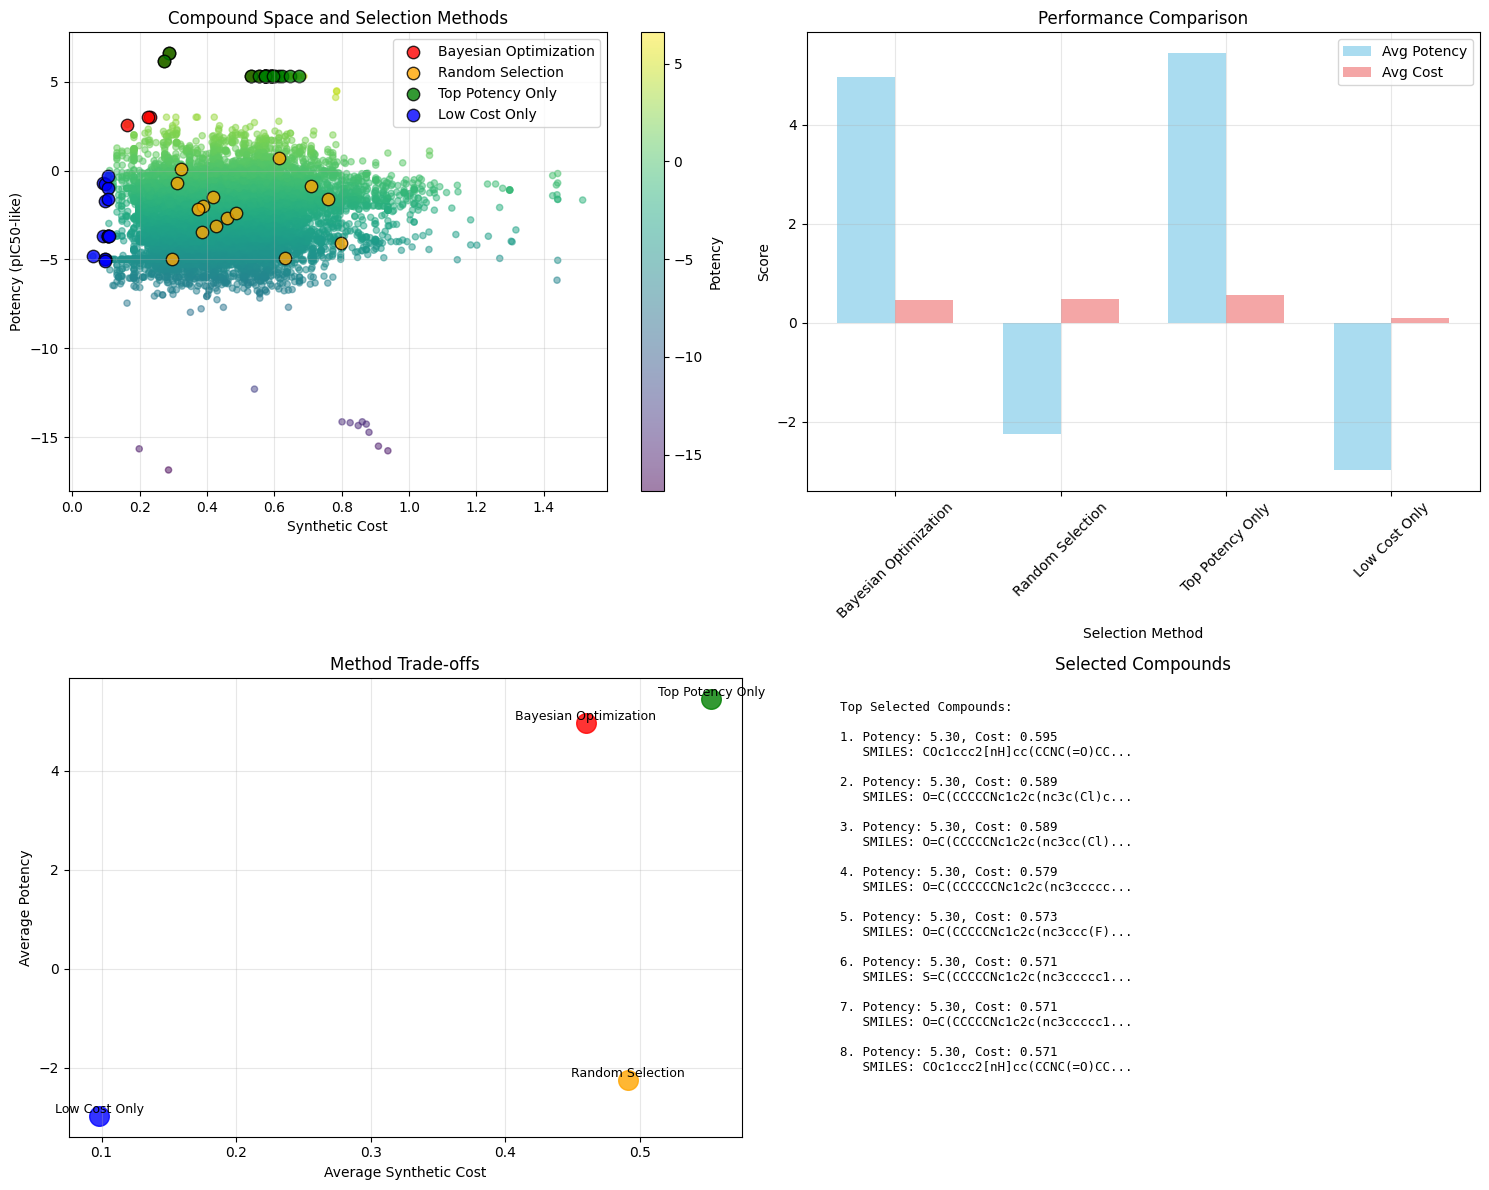


=== OPTIMIZATION COMPLETE ===
Bayesian optimization has successfully identified compounds balancing potency and synthetic cost!


In [32]:
def analyze_and_visualize_results(optimal_indices, data):
    """Comprehensive analysis and visualization of results"""
    
    optimal_compounds = data.iloc[optimal_indices]
    
    print("=== OPTIMAL COMPOUNDS ANALYSIS ===")
    print(f"Selected {len(optimal_compounds)} compounds")
    
    # Basic statistics
    print(f"\nPotency stats: {optimal_compounds['potency'].mean():.3f} ± {optimal_compounds['potency'].std():.3f}")
    print(f"Cost stats: {optimal_compounds['synthetic_cost'].mean():.3f} ± {optimal_compounds['synthetic_cost'].std():.3f}")
    
    # Create comparison baselines
    n_compare = len(optimal_indices)
    random_indices = np.random.choice(len(data), size=n_compare, replace=False)
    top_potency_indices = data['potency'].nlargest(n_compare).index
    low_cost_indices = data['synthetic_cost'].nsmallest(n_compare).index
    
    comparison_data = {
        'Bayesian Optimization': data.iloc[optimal_indices],
        'Random Selection': data.iloc[random_indices],
        'Top Potency Only': data.loc[top_potency_indices],
        'Low Cost Only': data.loc[low_cost_indices]
    }
    
    print("\n=== METHOD COMPARISON ===")
    comparison_results = []
    for method, compounds in comparison_data.items():
        avg_potency = compounds['potency'].mean()
        avg_cost = compounds['synthetic_cost'].mean()
        comparison_results.append({
            'Method': method,
            'Avg Potency': avg_potency,
            'Avg Cost': avg_cost,
            'Potency/Cost Ratio': avg_potency / avg_cost if avg_cost > 0 else 0
        })
        print(f"{method:20} | Potency: {avg_potency:7.3f} | Cost: {avg_cost:7.3f} | Ratio: {avg_potency/avg_cost if avg_cost > 0 else 0:7.3f}")
    
    # Create visualizations
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Plot 1: Scatter plot with selections
    scatter = axes[0,0].scatter(data['synthetic_cost'], data['potency'], 
                               c=data['potency'], alpha=0.5, cmap='viridis', s=20)
    
    colors = ['red', 'orange', 'green', 'blue']
    for i, (method, compounds) in enumerate(comparison_data.items()):
        axes[0,0].scatter(compounds['synthetic_cost'], compounds['potency'],
                         color=colors[i], label=method, s=80, alpha=0.8, edgecolors='black')
    
    axes[0,0].set_xlabel('Synthetic Cost')
    axes[0,0].set_ylabel('Potency (pIC50-like)')
    axes[0,0].set_title('Compound Space and Selection Methods')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[0,0], label='Potency')
    
    # Plot 2: Performance comparison bar chart
    methods = [r['Method'] for r in comparison_results]
    potencies = [r['Avg Potency'] for r in comparison_results]
    costs = [r['Avg Cost'] for r in comparison_results]
    
    x = np.arange(len(methods))
    width = 0.35
    
    axes[0,1].bar(x - width/2, potencies, width, label='Avg Potency', alpha=0.7, color='skyblue')
    axes[0,1].bar(x + width/2, costs, width, label='Avg Cost', alpha=0.7, color='lightcoral')
    axes[0,1].set_xlabel('Selection Method')
    axes[0,1].set_ylabel('Score')
    axes[0,1].set_title('Performance Comparison')
    axes[0,1].set_xticks(x)
    axes[0,1].set_xticklabels(methods, rotation=45)
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)
    
    # Plot 3: Trade-off analysis
    for i, (method, compounds) in enumerate(comparison_data.items()):
        axes[1,0].scatter(compounds['synthetic_cost'].mean(), 
                         compounds['potency'].mean(),
                         s=200, color=colors[i], label=method, alpha=0.8)
        axes[1,0].text(compounds['synthetic_cost'].mean(), 
                      compounds['potency'].mean(), 
                      method, fontsize=9, ha='center', va='bottom')
    
    axes[1,0].set_xlabel('Average Synthetic Cost')
    axes[1,0].set_ylabel('Average Potency')
    axes[1,0].set_title('Method Trade-offs')
    axes[1,0].grid(True, alpha=0.3)
    
    # Plot 4: Show top selected compounds
    top_selected = optimal_compounds.head(8)
    if 'canonical_smiles' in top_selected.columns:
        info_text = "Top Selected Compounds:\n\n"
        for i, (idx, row) in enumerate(top_selected.iterrows()):
            smiles = str(row['canonical_smiles'])
            short_smiles = (smiles[:25] + '...') if len(smiles) > 25 else smiles
            info_text += f"{i+1}. Potency: {row['potency']:.2f}, Cost: {row['synthetic_cost']:.3f}\n"
            info_text += f"   SMILES: {short_smiles}\n\n"
    else:
        info_text = "Top Selected Compounds:\n\n"
        for i, (idx, row) in enumerate(top_selected.iterrows()):
            info_text += f"{i+1}. Potency: {row['potency']:.2f}, Cost: {row['synthetic_cost']:.3f}\n"
            if 'molecule_chembl_id' in row:
                info_text += f"   ChEMBL ID: {row['molecule_chembl_id']}\n\n"
            else:
                info_text += "\n"
    
    axes[1,1].text(0.05, 0.95, info_text, fontsize=9, family='monospace', 
                  verticalalignment='top', transform=axes[1,1].transAxes)
    axes[1,1].set_xlim(0, 1)
    axes[1,1].set_ylim(0, 1)
    axes[1,1].set_title('Selected Compounds')
    axes[1,1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return comparison_data, comparison_results

# Run analysis
comparison_data, comparison_results = analyze_and_visualize_results(optimal_indices, robust_optimizer.data)

print("\n=== OPTIMIZATION COMPLETE ===")
print("Bayesian optimization has successfully identified compounds balancing potency and synthetic cost!")

In [20]:
print(df['document_chembl_id'].head(5))


0    CHEMBL1148382
1    CHEMBL1148382
2    CHEMBL1148382
3    CHEMBL1148382
4    CHEMBL1148382
Name: document_chembl_id, dtype: object
